# Polynomial Regression with Plot

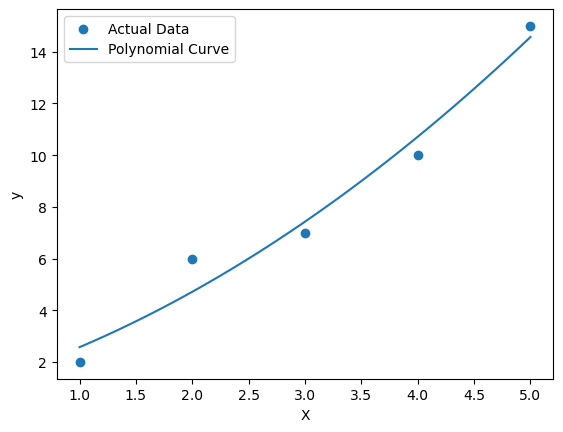

Intercept: 0.9999999999999964
Coefficients: [0.         1.28571429 0.28571429]


In [56]:
from ast import mod
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Dataset
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 6, 7, 10, 15])

# Convert to polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Model
model = LinearRegression()
model.fit(X_poly, y)

# Predictions for Smooth Curve
X_range = np.linspace(1, 5, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_pred = model.predict(X_range_poly)

# Plot
plt.scatter(X, y, label = "Actual Data")
plt.plot(X_range, y_pred, label = "Polynomial Curve")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

C:\Users\suluc\AppData\Local\Temp\ipykernel_23820\1358578440.py:9: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(X, y, 5)


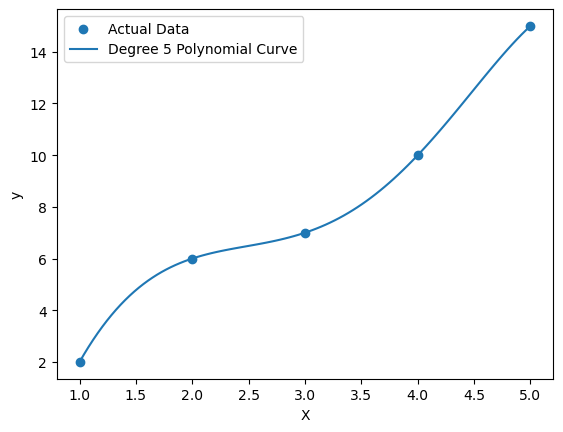

Polynomial Equation:
          5         4          3         2
-0.03155 x + 0.265 x + 0.2347 x - 6.692 x + 19.44 x - 11.21

Coefficients:
[ -0.03155235   0.26495198   0.23471653  -6.6923869   19.43798819
 -11.21371746]


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 6, 7, 10, 15])

# Fit a degree 5 polynomial equation
coefficients = np.polyfit(X, y, 5)

# Create polynomial equation
equation = np.poly1d(coefficients)

# Generate smooth curve points
X_range = np.linspace(1, 5, 100)
y_pred = equation(X_range)

# Plot
plt.scatter(X, y, label="Actual Data")
plt.plot(X_range, y_pred, label="Degree 5 Polynomial Curve")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Print polynomial equation
print("Polynomial Equation:")
print(equation)

# Print coefficients
print("\nCoefficients:")
print(coefficients)

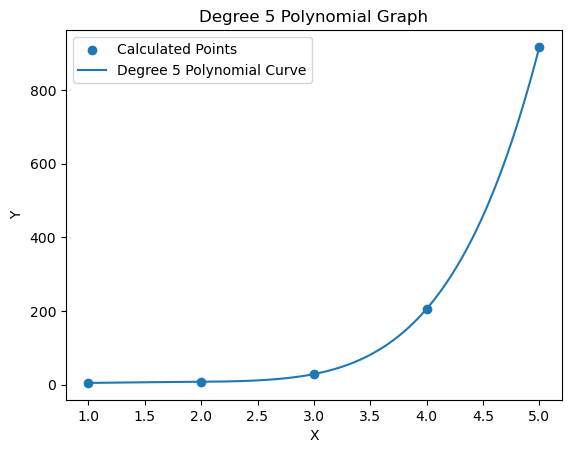

X values: [1 2 3 4 5]
Y values: [  5   8  29 206 917]


In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Given data points
X = np.array([1, 2, 3, 4, 5])

# Manually written degree 5 polynomial equation
# y = x^5 - 5x^4 + 8x^3 - 4x^2 + 3x + 2

def polynomial(x):
    return x**5 - 5*x**4 + 8*x**3 - 4*x**2 + 3*x + 2

# Calculate y values
y = polynomial(X)

# Smooth curve for graph
X_range = np.linspace(1, 5, 200)
y_range = polynomial(X_range)

# Plotting
plt.scatter(X, y, label="Calculated Points")
plt.plot(X_range, y_range, label="Degree 5 Polynomial Curve")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Degree 5 Polynomial Graph")
plt.legend()

plt.show()

# Print values
print("X values:", X)
print("Y values:", y)

# Implementation of classification KNN

In [59]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Training Dataset
X_train = np.array([
    [2, 50],
    [3, 55],
    [2, 45],
    [4, 60],
    [3, 50],
    [5, 65],
    [6, 70],
    [7, 75],
    [8, 80],
    [6, 78],
    [7, 82],
    [8, 85],
    [9, 88],
    [10, 90],
    [8, 92],
    [9, 95],
    [10, 96],
    [7, 89],
    [8, 84],
    [9, 91]
])

# Labels 0 = fail, 1 = pass

y_train = np.array([
    0,0,0,0,0,
    0,0,
    1,1,1,
    1,1,1,1,1,
    1,1,1,1,1

])

print("Training Samples:",len(X_train))

# Testing Dataset

X_test = np.array([
    [4, 55],
    [6, 72],
    [9, 90],
    [3, 52],
    [8, 88]
])

y_test = np.array([
    0,
    0,
    1,
    0,
    1
])

print("Testing Samples: ", len(X_test))


# Train Model

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Prediction

prediction=model.predict(X_test)
print("\n Pedicted:")
print(prediction)

print("\nActual:")
print(y_test)

# Accuracy

acc=accuracy_score(
    y_test,
    prediction
)

print("\nAccuracy:",acc)

# Confusion Matrix

print("\n Confusion Matrix: ")
print(confusion_matrix(
    y_test,
    prediction
))

# Classification Report

print("\nClassification Report: ")
print(classification_report(
    y_test,
    prediction
))

Training Samples: 20
Testing Samples:  5

 Pedicted:
[0 1 1 0 1]

Actual:
[0 0 1 0 1]

Accuracy: 0.8

 Confusion Matrix: 
[[2 1]
 [0 2]]

Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



# Image Classification using SVM + HOG

In [62]:
# Import Libraries

import os
import cv2
import numpy as np

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [63]:
# Load dataset and extract HOG features

dataset_path = "dataset"

IMG_SIZE = 128

images = []
labels = []

for label in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, label)

    if not os.path.isdir(class_path):
        continue

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm="L2-Hys"
        )

        images.append(features)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Feature Shape:", X.shape)
print("Classes:", np.unique(y))

Feature Shape: (975, 8100)
Classes: ['AiArtData' 'RealArt']


In [64]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [65]:
# Scale features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
# Train SVM

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm.fit(X_train, y_train)

print("Training completed.")

Training completed.


In [67]:
# Predict

y_pred = svm.predict(X_test)

In [68]:
# Evaluate

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6

Classification Report
              precision    recall  f1-score   support

   AiArtData       0.62      0.71      0.66       108
     RealArt       0.56      0.46      0.51        87

    accuracy                           0.60       195
   macro avg       0.59      0.59      0.59       195
weighted avg       0.60      0.60      0.59       195


Confusion Matrix
[[77 31]
 [47 40]]
